In [1]:
!git clone https://github.com/Niharika5389/LGCCA-FER.git

fatal: destination path 'LGCCA-FER' already exists and is not an empty directory.


In [2]:
!ls
%cd LGCCA-FER

LGCCA-FER
/kaggle/working/LGCCA-FER


In [3]:
!pip install -r requirements.txt

In [4]:
import os

print(os.listdir("/kaggle/input"))
dataset_path = "/kaggle/input/datasets/msambare/fer2013"

print(os.listdir(dataset_path))

['datasets']
['test', 'train']


In [5]:
!git pull origin main

From https://github.com/Niharika5389/LGCCA-FER
 * branch            main       -> FETCH_HEAD
Already up to date.


In [6]:
from configs.config import *
from data.dataset import *
from data.transforms import *

In [7]:
!cat data/dataset.py

import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder

from configs.config import DATASET_PATH, BATCH_SIZE
from data.transforms import train_transform, val_transform


def get_dataloaders():
    """
    Creates DataLoaders for training, validation and testing.
    """

    # Load the same training folder twice.
    # One copy will use training augmentation.
    # The other copy will use validation transforms.
    train_dataset = ImageFolder(
        root=f"{DATASET_PATH}/train",
        transform=train_transform
    )

    val_dataset = ImageFolder(
        root=f"{DATASET_PATH}/train",
        transform=val_transform
    )

    test_dataset = ImageFolder(
        root=f"{DATASET_PATH}/test",
        transform=val_transform
    )

    # Make results reproducible.
    torch.manual_seed(42)

    # Generate shuffled indices.
    indices = torch.randperm(len(train_dataset)).tolist()

    train_size = int(0.8 * len(indices))

    train_ind

In [8]:
# Import PyTorch
import torch

# Used for displaying images
import matplotlib.pyplot as plt

# Utility to arrange images into a grid
from torchvision.utils import make_grid

# Import our custom dataloader function
from data.dataset import get_dataloaders

In [9]:
# Create the training, validation and test dataloaders
train_loader, val_loader, test_loader = get_dataloaders()

In [10]:
# Print how many batches are present

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Testing batches    : {len(test_loader)}")

Training batches   : 718
Validation batches : 180
Testing batches    : 225


In [11]:
# ImageFolder automatically stores the class names

print(train_loader.dataset.dataset.classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [12]:
# Get one batch of images

images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


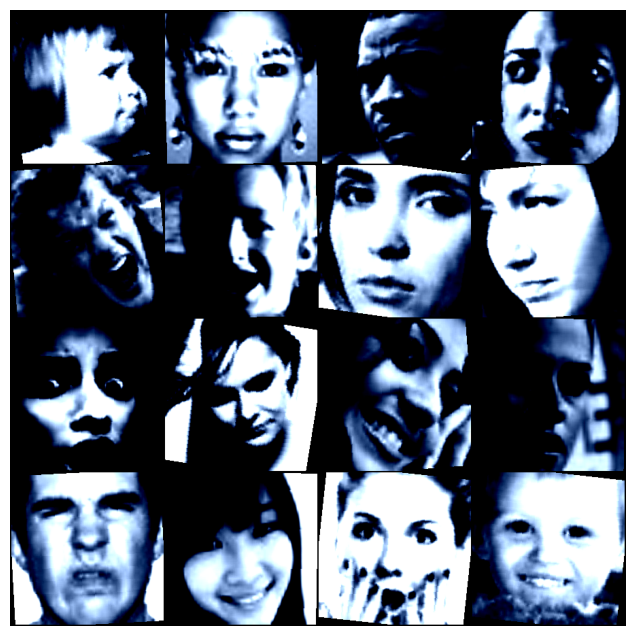

In [13]:
# Create a grid of images

grid = make_grid(images[:16], nrow=4)

# Convert tensor into NumPy format for plotting
grid = grid.permute(1, 2, 0)

plt.figure(figsize=(8, 8))
plt.imshow(grid)
plt.axis("off")
plt.show()

In [14]:
# Print the labels for the displayed images

print(labels[:16])

tensor([5, 4, 0, 5, 0, 3, 5, 5, 2, 2, 3, 5, 1, 3, 6, 3])


In [15]:
from models.backbone import EfficientNetBackbone
import torch

model = EfficientNetBackbone()

dummy = torch.randn(4, 3, 224, 224)

output = model(dummy)

print(output.shape)

torch.Size([4, 7])
